# Assignment 1: Frequent Pattern Mining

## Task 1: Data Inspection and Preparation

### a) Understanding and Pruning the Data

In [1]:
! pip install pandas
! pip install matplotlib
! pip install mlxtend


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
#Libraries

# Data tools
import pandas as pd
import numpy as np
import random

# Graphs
import matplotlib.pyplot as plt

# Needed for Apriori
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from IPython.display import display

In [3]:
# Load data
orders_raw = pd.read_csv("../assignment1-dataset/raw/orders.csv")
order_products_raw = pd.read_csv("../assignment1-dataset/raw/order_products.csv")
products_raw = pd.read_csv("../assignment1-dataset/raw/products.csv")

In [4]:
# Create copies to perform sampling without altering the raw data
orders = orders_raw.copy()
order_products = order_products_raw.copy()
products = products_raw.copy()

In [5]:
orders.head()

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,1,2,8,NaN
1,2398795,1,2,3,7,15.0
2,473747,1,3,3,12,21.0
3,2254736,1,4,4,7,29.0
4,431534,1,5,4,15,28.0


In [6]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3421083 entries, 0 to 3421082
Data columns (total 6 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   order_id                int64  
 1   user_id                 int64  
 2   order_number            int64  
 3   order_dow               int64  
 4   order_hour_of_day       int64  
 5   days_since_prior_order  float64
dtypes: float64(1), int64(5)
memory usage: 156.6 MB


In [7]:
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


In [8]:
order_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33819106 entries, 0 to 33819105
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 1.0 GB


In [9]:
products.head()

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


In [10]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49688 entries, 0 to 49687
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49688 non-null  int64 
 1   product_name   49688 non-null  object
 2   aisle_id       49688 non-null  int64 
 3   department_id  49688 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


In [11]:
# Randomly sample 50,000 orders using a fixed seed for consistent results
sampled_orders = orders.sample(n=50000, random_state=10)
print(sampled_orders.shape)

(50000, 6)


In [12]:
# Get the order IDs we sampled
sampled_order_ids = sampled_orders["order_id"]

# Keep only the products that belong to those sampled orders
sampled_order_products = order_products[
    order_products["order_id"].isin(sampled_order_ids)
]

# Add the product names so it is easier to read later
sampled_order_products = sampled_order_products.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

# Print the shape to see how many rows we have now
print(sampled_order_products.shape)

(495204, 5)


First, 50,000 orders were randomly sampled from the orders table to reduce the dataset size. Then, the order_products table was filtered to keep only the products that belong to those sampled orders and merged with the products table to include product names for better readability. In the end, 50,000 transactions were obtained, represented by 495,204 rows.

In [13]:
print("Original rows:", len(order_products))
print("Sampled rows:", len(sampled_order_products))

Original rows: 33819106
Sampled rows: 495204


In [14]:
print("Original unique products:", order_products["product_id"].nunique())
print("Sampled unique products:", sampled_order_products["product_id"].nunique())

Original unique products: 49685
Sampled unique products: 29068


Although the number of unique products decreased from 49,685 to 29,068 after sampling, the set of products appearing in the sample still covers about 98 percent of all rows in the original order_products table. 

This means that most product purchase records in the original dataset are associated with products that remain present in the reduced dataset. 

Therefore, products missing from the sample account for only a small fraction of total product level records and are likely very infrequent items.

In [15]:
# Products that appear in the sample
sample_products = set(sampled_order_products["product_id"].unique())

# Original rows that correspond to those products
rows_kept_in_original = order_products[
    order_products["product_id"].isin(sample_products)
]

print("Total rows in original order_products:",
      len(order_products))

print("Original order_products rows covered by sampled products:",
      len(rows_kept_in_original))

print("Share of original order_products rows represented in the sample:",
      len(rows_kept_in_original) / len(order_products) * 100)

Total rows in original order_products: 33819106
Original order_products rows covered by sampled products: 33231052
Share of original order_products rows represented in the sample: 98.26117816360966


In [16]:
# Products that DO NOT appear in the sample
lost_products = set(order_products["product_id"].unique()) - sample_products

# Original rows corresponding to those lost products
rows_lost_in_original = order_products[
    order_products["product_id"].isin(lost_products)
]

print("Number of unique products lost after sampling:",
      len(lost_products))

print("Original order_products rows linked to lost products:",
      len(rows_lost_in_original))

print("Share of original order_products rows linked to lost products (%):",
      len(rows_lost_in_original) / len(order_products) * 100)

Number of unique products lost after sampling: 20617
Original order_products rows linked to lost products: 588054
Share of original order_products rows linked to lost products (%): 1.738821836390353


A comparison of the basket size distribution between the original dataset and the sample helps verify whether both look similar. If the shapes are close, this suggests that the sampling preserved the overall purchasing patterns. This complements the previous check on product coverage.

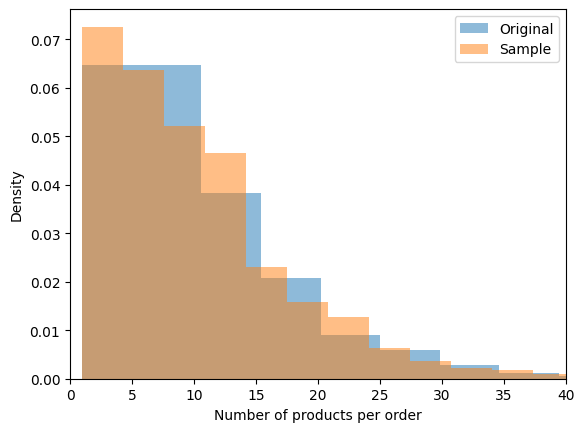

In [17]:
original_basket_sizes = order_products.groupby("order_id")["product_id"].nunique()
basket_sizes = sampled_order_products.groupby("order_id")["product_id"].nunique()

plt.figure()

plt.hist(original_basket_sizes, bins=30, density=True, alpha=0.5, label="Original")
plt.hist(basket_sizes, bins=30, density=True, alpha=0.5, label="Sample")

plt.xlim(0, 40)
plt.xlabel("Number of products per order")
plt.ylabel("Density")
plt.legend()
plt.show()

Based on the product coverage and the similar basket size distribution, the sample can be considered representative enough for this analysis.

### b) Constructing Transactions

Each order was considered a single transaction, where all products in the same order formed a basket.

The data was grouped by order_id, and the corresponding product_name values were collected into a list for each order. Duplicate products within the same order were removed.

Then, the transactions were converted into a one-hot encoded matrix using TransactionEncoder. In this matrix, each row represents an order and each column a product. A value of True indicates that the product appears in the order. This format is required to apply the Apriori algorithm.

In [18]:
# Group products by order_id to create one basket per order
transactions = (
    sampled_order_products
    .groupby("order_id")["product_name"]
    .apply(lambda x: list(x.unique()))
    .tolist()
)

print(transactions[:5])

[['Blueberries', 'Raspberries', 'Blackberries'], ['Organic Red Bell Pepper', 'Milk, Organic, Vitamin D', 'Sonoma Traditional Flour Tortillas 10 Count', 'Honey Greek Yogurt', 'Bag of Organic Bananas', 'Sparkling Water Grapefruit', 'Organic 1% Low Fat Milk', 'Organic Large Brown Grade AA Cage Free Eggs', 'Orange Bell Pepper', 'Pita Chips Simply Naked', 'Roasted Pumpkin White Cheddar Tamales', 'Organic High Fiber Oat Bran Hot Cereal'], ['Poultry & Beef Feast Variety  Cat Food', 'Silver Tequila', 'Imported Light Beer', 'Premium Belgian Lager'], ['Sparkling Natural Mineral Water', '9 Inch Plates', 'American Cheese slices', 'Organic Strawberries', 'Spring Water', 'Gluten Free Whole Grain Bread', 'Peanut Butter Cookie', 'Honeycrisp Apple', 'Cultured Low Fat Buttermilk', 'Gluten Free The Perfect 10 Crackers', 'Organic Strawberry Smoothie', 'Coconut Cream Pie', 'Multi-Seed Original Crackers', 'Premium Indian Tonic Water', 'Everything Inside Bagels', 'Organic Red Radish, Bunch'], ['Organic Extra

In [19]:
# Convert list of baskets into a one-hot encoded matrix
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

# DataFrame: rows = orders, columns = products, values = True/False
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded.head(3)


,#2 Coffee Filters,#4 Natural Brown Coffee Filters,& Go! Hazelnut Spread + Pretzel Sticks,(70% Juice!) Mountain Raspberry Juice Squeeze,+Energy Black Cherry Vegetable & Fruit Juice,0 Calorie Acai Raspberry Water Beverage,0 Calorie Fuji Apple Pear Water Beverage,0 Calorie Strawberry Dragonfruit Water Beverage,0% Fat Black Cherry Greek Yogurt y,0% Fat Blueberry Greek Yogurt,...,with Olive Oil Mayonnaise,with Olive Oil Mayonnaise Dressing,with Sweet & Smoky BBQ Sauce Cheeseburger Sliders,with Twist Ties Sandwich & Storage Bags,with Xylitol Cinnamon 18 Sticks Sugar Free Gum,with Xylitol Island Berry Lime 18 Sticks Sugar Free Gum,with Xylitol Original Flavor 18 Sticks Sugar Free Gum,with Xylitol Unwrapped Original Flavor 50 Sticks Sugar Free Gum,with Xylitol Unwrapped Spearmint 50 Sticks Sugar Free Gum,with a Splash of Pineapple Coconut Water
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


## Task 2: Mining Association Rules

### a) Exploring the Dataset

Apriori algorithm was executed using different values of `min_support`.

`min_support` tells the algorithm how often things need to appear together to be considered frequent. This parameter is mandatory for Apriori to work because a minimum threshold is required.

The following values were tested:
- 0.005 - 0.5%
- 0.01 - 1%
- 0.02 - 2%

In [20]:
supports = [0.005, 0.01, 0.02]

results_support = []

for s in supports:
    frequent = apriori(df_encoded, min_support=s, use_colnames=True)
    results_support.append((s, len(frequent)))

results_support

[(0.005, 338), (0.01, 120), (0.02, 42)]

In [21]:
frequent_dict = {}

for s in supports:
    frequent_dict[s] = apriori(df_encoded, min_support=s, use_colnames=True)

In [22]:
for s in supports:
    print(f"\nmin_support = {s}")
    display(frequent_dict[s].head())


min_support = 0.005


,support,itemsets
0,0.012494,(100% Raw Coconut Water)
1,0.008097,(100% Recycled Paper Towels)
2,0.020325,(100% Whole Wheat Bread)
3,0.011246,(2% Reduced Fat Milk)
4,0.005521,(2% Reduced Fat Organic Milk)



min_support = 0.01


,support,itemsets
0,0.012494,(100% Raw Coconut Water)
1,0.020325,(100% Whole Wheat Bread)
2,0.011246,(2% Reduced Fat Milk)
3,0.026562,(Apple Honeycrisp Organic)
4,0.021143,(Asparagus)



min_support = 0.02


,support,itemsets
0,0.020325,(100% Whole Wheat Bread)
1,0.026562,(Apple Honeycrisp Organic)
2,0.021143,(Asparagus)
3,0.117411,(Bag of Organic Bananas)
4,0.146795,(Banana)


In [23]:
for s in supports:
    print(f"\nmin_support = {s} ")
    display(frequent_dict[s].nlargest(5, "support"))


min_support = 0.005 


,support,itemsets
10,0.146795,(Banana)
9,0.117411,(Bag of Organic Bananas)
169,0.083448,(Organic Strawberries)
89,0.075698,(Organic Baby Spinach)
130,0.065065,(Organic Hass Avocado)



min_support = 0.01 


,support,itemsets
6,0.146795,(Banana)
5,0.117411,(Bag of Organic Bananas)
75,0.083448,(Organic Strawberries)
37,0.075698,(Organic Baby Spinach)
57,0.065065,(Organic Hass Avocado)



min_support = 0.02 


,support,itemsets
4,0.146795,(Banana)
3,0.117411,(Bag of Organic Bananas)
31,0.083448,(Organic Strawberries)
16,0.075698,(Organic Baby Spinach)
25,0.065065,(Organic Hass Avocado)


It is important to notice that when min_support increases, the rule becomes stricter, so fewer frequent itemsets appear.

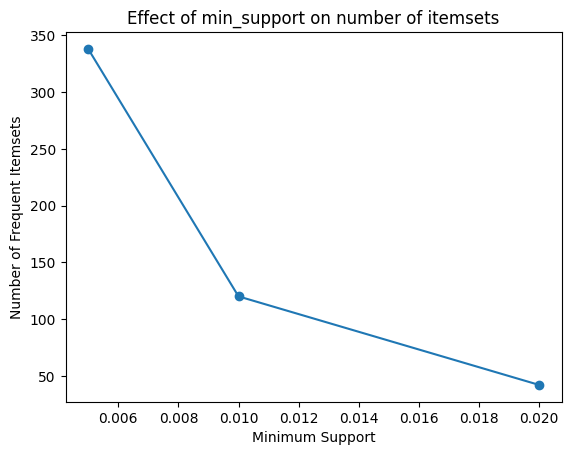

In [24]:
supports = [r[0] for r in results_support]
counts = [r[1] for r in results_support]

plt.figure()
plt.plot(supports, counts, marker='o')
plt.xlabel("Minimum Support")
plt.ylabel("Number of Frequent Itemsets")
plt.title("Effect of min_support on number of itemsets")
plt.show()

### b) Identifying Market Insights

- Product Categories: Extract rules involving product_id or aisle_id (e.g., “Item A is often purchased with Item B”). In this case, product_id was selected for the analysis.
**_Note 1: The execution of this task begins from cell 18._**
**_Note 2: product_name was used for readability._**

After support is defined, association rules are generated using `min_confidence`.

Confidence measures how reliable a rule is, and `min_confidence` sets the minimum reliability required to keep it. As `min_confidence` increases, fewer but stronger rules are generated.

In [25]:
frequent = apriori(df_encoded, min_support=0.005, use_colnames=True)

conf_levels = [0.1, 0.2, 0.3, 0.4]
rule_counts = []

for c in conf_levels:
    rules = association_rules(frequent, metric="confidence", min_threshold=c)
    rule_counts.append(len(rules))

list(zip(conf_levels, rule_counts))

[(0.1, 103), (0.2, 44), (0.3, 6), (0.4, 0)]

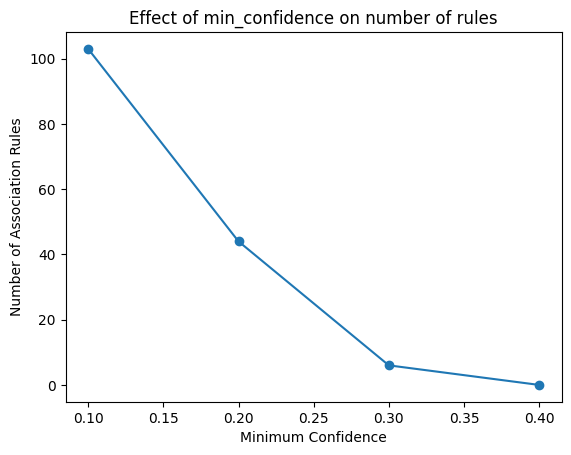

In [26]:
conf = [r[0] for r in zip(conf_levels, rule_counts)]
counts = [r[1] for r in zip(conf_levels, rule_counts)]

plt.figure()
plt.plot(conf_levels, rule_counts, marker='o')
plt.xlabel("Minimum Confidence")
plt.ylabel("Number of Association Rules")
plt.title("Effect of min_confidence on number of rules")
plt.show()

In [27]:
rules_dict = {}

for c in conf_levels:
    rules_dict[c] = association_rules(
        frequent,
        metric="confidence",
        min_threshold=c
    )

In [28]:
for c in conf_levels:
    rules = association_rules(frequent, metric="confidence", min_threshold=c)
    print(f"\n confidence >= {c}")
    display(rules.head())


 confidence >= 0.1


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(100% Whole Wheat Bread),(Banana),0.020325,0.146795,0.005357,0.263581,1.795578,1.0,0.002374,1.158587,0.452269,0.033118,0.136880,0.150038
1,(Apple Honeycrisp Organic),(Bag of Organic Bananas),0.026562,0.117411,0.007770,0.292533,2.491521,1.0,0.004652,1.247533,0.614973,0.057048,0.198418,0.179356
2,(Apple Honeycrisp Organic),(Banana),0.026562,0.146795,0.005010,0.188607,1.284832,1.0,0.001111,1.051531,0.227737,0.029758,0.049006,0.111367
3,(Apple Honeycrisp Organic),(Organic Hass Avocado),0.026562,0.065065,0.005092,0.191686,2.946072,1.0,0.003363,1.156648,0.678589,0.058837,0.135433,0.134969
4,(Large Lemon),(Bag of Organic Bananas),0.048236,0.117411,0.006441,0.133531,1.137294,1.0,0.000778,1.018604,0.126838,0.040457,0.018264,0.094195



 confidence >= 0.2


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(100% Whole Wheat Bread),(Banana),0.020325,0.146795,0.005357,0.263581,1.795578,1.0,0.002374,1.158587,0.452269,0.033118,0.136880,0.150038
1,(Apple Honeycrisp Organic),(Bag of Organic Bananas),0.026562,0.117411,0.007770,0.292533,2.491521,1.0,0.004652,1.247533,0.614973,0.057048,0.198418,0.179356
2,(Organic Baby Spinach),(Bag of Organic Bananas),0.075698,0.117411,0.015336,0.202593,1.725500,1.0,0.006448,1.106824,0.454892,0.086266,0.096514,0.166605
3,(Organic Blueberries),(Bag of Organic Bananas),0.032164,0.117411,0.006891,0.214240,1.824699,1.0,0.003114,1.123230,0.466985,0.048295,0.109710,0.136465
4,(Organic Cucumber),(Bag of Organic Bananas),0.026214,0.117411,0.007913,0.301872,2.571065,1.0,0.004835,1.264222,0.627506,0.058309,0.209000,0.184635



 confidence >= 0.3


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Organic Cucumber),(Bag of Organic Bananas),0.026214,0.117411,0.007913,0.301872,2.571065,1.0,0.004835,1.264222,0.627506,0.058309,0.209000,0.184635
1,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.022268,0.117411,0.007239,0.325069,2.768633,1.0,0.004624,1.307672,0.653360,0.054655,0.235282,0.193360
2,(Cucumber Kirby),(Banana),0.030099,0.146795,0.009304,0.309103,2.105683,1.0,0.004885,1.234924,0.541390,0.055515,0.190234,0.186241
3,(Honeycrisp Apple),(Banana),0.025110,0.146795,0.009242,0.368078,2.507433,1.0,0.005556,1.350175,0.616670,0.056820,0.259355,0.215520
4,(Organic Fuji Apple),(Banana),0.027952,0.146795,0.010694,0.382590,2.606288,1.0,0.006591,1.381909,0.634035,0.065188,0.276364,0.227720



 confidence >= 0.4


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Rules are sorted by confidence to highlight the strongest conditional relationships between products.

In [29]:
for c in conf_levels:
    print(f"\nconfidence >= {c}")
    
    display(
        rules_dict[c]
        .assign(confidence=pd.to_numeric(rules_dict[c]["confidence"], errors="coerce"))
        .sort_values("confidence", ascending=False)
        .head(10)
    )


confidence >= 0.1


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
39,(Organic Fuji Apple),(Banana),0.027952,0.146795,0.010694,0.382590,2.606288,1.0,0.006591,1.381909,0.634035,0.065188,0.276364,0.227720
30,(Honeycrisp Apple),(Banana),0.025110,0.146795,0.009242,0.368078,2.507433,1.0,0.005556,1.350175,0.616670,0.056820,0.259355,0.215520
16,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.022268,0.117411,0.007239,0.325069,2.768633,1.0,0.004624,1.307672,0.653360,0.054655,0.235282,0.193360
28,(Cucumber Kirby),(Banana),0.030099,0.146795,0.009304,0.309103,2.105683,1.0,0.004885,1.234924,0.541390,0.055515,0.190234,0.186241
54,(Yellow Onions),(Banana),0.022902,0.146795,0.006973,0.304464,2.074081,1.0,0.003611,1.226688,0.529996,0.042850,0.184797,0.175982
10,(Organic Cucumber),(Bag of Organic Bananas),0.026214,0.117411,0.007913,0.301872,2.571065,1.0,0.004835,1.264222,0.627506,0.058309,0.209000,0.184635
52,(Seedless Red Grapes),(Banana),0.025396,0.146795,0.007607,0.299517,2.040378,1.0,0.003879,1.218024,0.523182,0.046217,0.178998,0.175667
15,(Organic Hass Avocado),(Bag of Organic Bananas),0.065065,0.117411,0.019446,0.298869,2.545484,1.0,0.011807,1.258806,0.649401,0.119278,0.205597,0.232245
26,(Blueberries),(Banana),0.017197,0.146795,0.005092,0.296076,2.016939,1.0,0.002567,1.212070,0.513021,0.032042,0.174965,0.165380
51,(Red Peppers),(Banana),0.017135,0.146795,0.005071,0.295943,2.016030,1.0,0.002556,1.211841,0.512762,0.031922,0.174809,0.165244



confidence >= 0.2


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
25,(Organic Fuji Apple),(Banana),0.027952,0.146795,0.010694,0.382590,2.606288,1.0,0.006591,1.381909,0.634035,0.065188,0.276364,0.227720
19,(Honeycrisp Apple),(Banana),0.025110,0.146795,0.009242,0.368078,2.507433,1.0,0.005556,1.350175,0.616670,0.056820,0.259355,0.215520
9,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.022268,0.117411,0.007239,0.325069,2.768633,1.0,0.004624,1.307672,0.653360,0.054655,0.235282,0.193360
17,(Cucumber Kirby),(Banana),0.030099,0.146795,0.009304,0.309103,2.105683,1.0,0.004885,1.234924,0.541390,0.055515,0.190234,0.186241
34,(Yellow Onions),(Banana),0.022902,0.146795,0.006973,0.304464,2.074081,1.0,0.003611,1.226688,0.529996,0.042850,0.184797,0.175982
4,(Organic Cucumber),(Bag of Organic Bananas),0.026214,0.117411,0.007913,0.301872,2.571065,1.0,0.004835,1.264222,0.627506,0.058309,0.209000,0.184635
32,(Seedless Red Grapes),(Banana),0.025396,0.146795,0.007607,0.299517,2.040378,1.0,0.003879,1.218024,0.523182,0.046217,0.178998,0.175667
8,(Organic Hass Avocado),(Bag of Organic Bananas),0.065065,0.117411,0.019446,0.298869,2.545484,1.0,0.011807,1.258806,0.649401,0.119278,0.205597,0.232245
15,(Blueberries),(Banana),0.017197,0.146795,0.005092,0.296076,2.016939,1.0,0.002567,1.212070,0.513021,0.032042,0.174965,0.165380
31,(Red Peppers),(Banana),0.017135,0.146795,0.005071,0.295943,2.016030,1.0,0.002556,1.211841,0.512762,0.031922,0.174809,0.165244



confidence >= 0.3


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(Organic Fuji Apple),(Banana),0.027952,0.146795,0.010694,0.382590,2.606288,1.0,0.006591,1.381909,0.634035,0.065188,0.276364,0.227720
3,(Honeycrisp Apple),(Banana),0.025110,0.146795,0.009242,0.368078,2.507433,1.0,0.005556,1.350175,0.616670,0.056820,0.259355,0.215520
1,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.022268,0.117411,0.007239,0.325069,2.768633,1.0,0.004624,1.307672,0.653360,0.054655,0.235282,0.193360
2,(Cucumber Kirby),(Banana),0.030099,0.146795,0.009304,0.309103,2.105683,1.0,0.004885,1.234924,0.541390,0.055515,0.190234,0.186241
5,(Yellow Onions),(Banana),0.022902,0.146795,0.006973,0.304464,2.074081,1.0,0.003611,1.226688,0.529996,0.042850,0.184797,0.175982
0,(Organic Cucumber),(Bag of Organic Bananas),0.026214,0.117411,0.007913,0.301872,2.571065,1.0,0.004835,1.264222,0.627506,0.058309,0.209000,0.184635



confidence >= 0.4


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


Rules are sorted by support to identify the most frequent co-purchasing patterns in the sample; depending on the direction of the rule, they represent different conditional relationships between products.

In [30]:
for c in conf_levels:
    print(f"\nconfidence >= {c}")
    display(
        rules_dict[c]
        .assign(support=pd.to_numeric(rules_dict[c]["support"], errors="coerce"))
        .sort_values("support", ascending=False)
        .head(10)
    )


confidence >= 0.1


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
21,(Organic Strawberries),(Bag of Organic Bananas),0.083448,0.117411,0.020039,0.240137,2.045265,1.0,0.010241,1.161511,0.557596,0.110822,0.139052,0.205405
20,(Bag of Organic Bananas),(Organic Strawberries),0.117411,0.083448,0.020039,0.170672,2.045265,1.0,0.010241,1.105175,0.579053,0.110822,0.095166,0.205405
14,(Bag of Organic Bananas),(Organic Hass Avocado),0.117411,0.065065,0.019446,0.165622,2.545484,1.0,0.011807,1.120517,0.687917,0.119278,0.107555,0.232245
15,(Organic Hass Avocado),(Bag of Organic Bananas),0.065065,0.117411,0.019446,0.298869,2.545484,1.0,0.011807,1.258806,0.649401,0.119278,0.205597,0.232245
46,(Organic Strawberries),(Banana),0.083448,0.146795,0.017851,0.213918,1.457260,1.0,0.005601,1.085390,0.342349,0.084047,0.078672,0.167761
45,(Banana),(Organic Strawberries),0.146795,0.083448,0.017851,0.121605,1.457260,1.0,0.005601,1.043440,0.367767,0.084047,0.041631,0.167761
33,(Organic Avocado),(Banana),0.056334,0.146795,0.016645,0.295463,2.012761,1.0,0.008375,1.211015,0.533207,0.089254,0.174246,0.204425
34,(Banana),(Organic Avocado),0.146795,0.056334,0.016645,0.113386,2.012761,1.0,0.008375,1.064349,0.589741,0.089254,0.060458,0.204425
37,(Banana),(Organic Baby Spinach),0.146795,0.075698,0.015867,0.108093,1.427955,1.0,0.004755,1.036321,0.351261,0.076794,0.035048,0.158855
36,(Organic Baby Spinach),(Banana),0.075698,0.146795,0.015867,0.209616,1.427955,1.0,0.004755,1.079482,0.324242,0.076794,0.073630,0.158855



confidence >= 0.2


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
12,(Organic Strawberries),(Bag of Organic Bananas),0.083448,0.117411,0.020039,0.240137,2.045265,1.0,0.010241,1.161511,0.557596,0.110822,0.139052,0.205405
8,(Organic Hass Avocado),(Bag of Organic Bananas),0.065065,0.117411,0.019446,0.298869,2.545484,1.0,0.011807,1.258806,0.649401,0.119278,0.205597,0.232245
28,(Organic Strawberries),(Banana),0.083448,0.146795,0.017851,0.213918,1.457260,1.0,0.005601,1.085390,0.342349,0.084047,0.078672,0.167761
22,(Organic Avocado),(Banana),0.056334,0.146795,0.016645,0.295463,2.012761,1.0,0.008375,1.211015,0.533207,0.089254,0.174246,0.204425
24,(Organic Baby Spinach),(Banana),0.075698,0.146795,0.015867,0.209616,1.427955,1.0,0.004755,1.079482,0.324242,0.076794,0.073630,0.158855
2,(Organic Baby Spinach),(Bag of Organic Bananas),0.075698,0.117411,0.015336,0.202593,1.725500,1.0,0.006448,1.106824,0.454892,0.086266,0.096514,0.166605
20,(Large Lemon),(Banana),0.048236,0.146795,0.012903,0.267486,1.822178,1.0,0.005822,1.164763,0.474074,0.070843,0.141456,0.177691
33,(Strawberries),(Banana),0.043799,0.146795,0.012821,0.292717,1.994056,1.0,0.006391,1.206314,0.521344,0.072119,0.171028,0.190028
11,(Organic Raspberries),(Bag of Organic Bananas),0.042756,0.117411,0.012044,0.281683,2.399116,1.0,0.007024,1.228690,0.609228,0.081309,0.186125,0.192130
43,(Organic Raspberries),(Organic Strawberries),0.042756,0.083448,0.010796,0.252511,3.025984,1.0,0.007229,1.226175,0.699434,0.093551,0.184456,0.190945



confidence >= 0.3


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(Organic Fuji Apple),(Banana),0.027952,0.146795,0.010694,0.382590,2.606288,1.0,0.006591,1.381909,0.634035,0.065188,0.276364,0.227720
2,(Cucumber Kirby),(Banana),0.030099,0.146795,0.009304,0.309103,2.105683,1.0,0.004885,1.234924,0.541390,0.055515,0.190234,0.186241
3,(Honeycrisp Apple),(Banana),0.025110,0.146795,0.009242,0.368078,2.507433,1.0,0.005556,1.350175,0.616670,0.056820,0.259355,0.215520
0,(Organic Cucumber),(Bag of Organic Bananas),0.026214,0.117411,0.007913,0.301872,2.571065,1.0,0.004835,1.264222,0.627506,0.058309,0.209000,0.184635
1,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.022268,0.117411,0.007239,0.325069,2.768633,1.0,0.004624,1.307672,0.653360,0.054655,0.235282,0.193360
5,(Yellow Onions),(Banana),0.022902,0.146795,0.006973,0.304464,2.074081,1.0,0.003611,1.226688,0.529996,0.042850,0.184797,0.175982



confidence >= 0.4


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski


-  Purchase Timing: Extract patterns involving order_dow or order_hour_of_day (e.g., “Purchases made in the morning are associated with certain product categories”).

In [31]:
sampled_full = sampled_order_products.merge(
    sampled_orders[["order_id", "order_dow", "order_hour_of_day"]],
    on="order_id", how="left"
)

In [32]:
# Convert numeric day values into day names
dow_map = {
    0: "sunday", 1: "monday", 2: "tuesday",
    3: "wednesday", 4: "thursday",
    5: "friday", 6: "saturday"
}

sampled_full["dow_label"] = sampled_full["order_dow"].map(dow_map)

In [33]:
# How orders are distributed across the different hours of the day
sampled_orders["order_hour_of_day"].value_counts().sort_index()

order_hour_of_day
0      357
1      158
2      107
3       77
4       90
5      134
6      506
7     1327
8     2636
9     3803
10    4114
11    4144
12    4039
13    4155
14    4108
15    4114
16    3941
17    3257
18    2727
19    2062
20    1517
21    1167
22     879
23     581
Name: count, dtype: int64

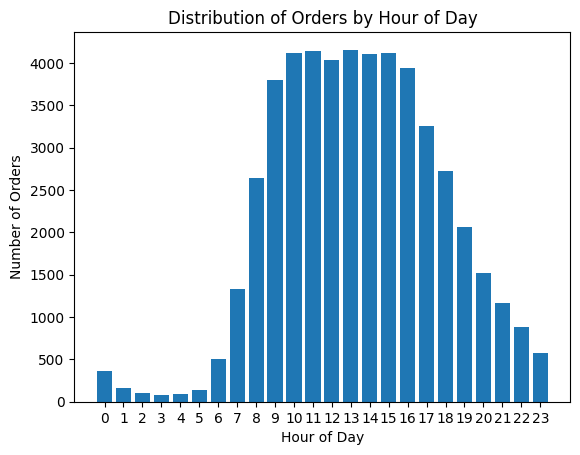

In [34]:
# Hourly distribution to create a visualization
hour_counts = sampled_orders["order_hour_of_day"].value_counts().sort_index()

# Plot the number of orders for each hour
plt.figure()
plt.bar(hour_counts.index, hour_counts.values)

plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Distribution of Orders by Hour of Day")

plt.xticks(range(24))
plt.show()

In [35]:
# Group hours into time periods
sampled_full["time_label"] = sampled_full["order_hour_of_day"].apply(
    lambda h:
        "morning" if 6 <= h < 12 else
        "afternoon" if 12 <= h < 18 else
        "evening" if 18 <= h < 23 else
        "night"
)

In [36]:
# Transactions that include products with day and time information
transactions_time = (
    sampled_full
    .groupby("order_id")
    .apply(lambda x:
        list(x["product_name"].unique()) +
        [x["time_label"].iloc[0]] +
        [x["dow_label"].iloc[0]],
        include_groups=False # do not include order_id inside the grouped DataFrame
    )
    .tolist()
)

In [37]:
timing_encoder = TransactionEncoder()
timing_encoded_array = timing_encoder.fit(transactions_time).transform(transactions_time)
timing_encoded_df = pd.DataFrame(timing_encoded_array, columns=timing_encoder.columns_)
timing_encoded_df.head()

,#2 Coffee Filters,#4 Natural Brown Coffee Filters,& Go! Hazelnut Spread + Pretzel Sticks,(70% Juice!) Mountain Raspberry Juice Squeeze,+Energy Black Cherry Vegetable & Fruit Juice,0 Calorie Acai Raspberry Water Beverage,0 Calorie Fuji Apple Pear Water Beverage,0 Calorie Strawberry Dragonfruit Water Beverage,0% Fat Black Cherry Greek Yogurt y,0% Fat Blueberry Greek Yogurt,...,with Olive Oil Mayonnaise,with Olive Oil Mayonnaise Dressing,with Sweet & Smoky BBQ Sauce Cheeseburger Sliders,with Twist Ties Sandwich & Storage Bags,with Xylitol Cinnamon 18 Sticks Sugar Free Gum,with Xylitol Island Berry Lime 18 Sticks Sugar Free Gum,with Xylitol Original Flavor 18 Sticks Sugar Free Gum,with Xylitol Unwrapped Original Flavor 50 Sticks Sugar Free Gum,with Xylitol Unwrapped Spearmint 50 Sticks Sugar Free Gum,with a Splash of Pineapple Coconut Water
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [38]:
# Test different min_support values
timing_supports = [0.005, 0.01, 0.02]
timing_itemset_counts = []

for s in timing_supports:
    itemsets = apriori(timing_encoded_df, min_support=s, use_colnames=True)
    timing_itemset_counts.append((s, len(itemsets)))

timing_itemset_counts

[(0.005, 688), (0.01, 238), (0.02, 93)]

In [39]:
# Store frequent itemsets for each support value so we can inspect them
timing_itemsets_by_support = {}

for s in timing_supports:
    timing_itemsets_by_support[s] = apriori(timing_encoded_df, min_support=s, use_colnames=True)

In [40]:
# Preview the first frequent itemsets found for each min_support value
for s in timing_supports:
    print(f"\nmin_support = {s}")
    display(timing_itemsets_by_support[s].head())


min_support = 0.005


,support,itemsets
0,0.012494,(100% Raw Coconut Water)
1,0.008097,(100% Recycled Paper Towels)
2,0.020325,(100% Whole Wheat Bread)
3,0.011246,(2% Reduced Fat Milk)
4,0.005521,(2% Reduced Fat Organic Milk)



min_support = 0.01


,support,itemsets
0,0.012494,(100% Raw Coconut Water)
1,0.020325,(100% Whole Wheat Bread)
2,0.011246,(2% Reduced Fat Milk)
3,0.026562,(Apple Honeycrisp Organic)
4,0.021143,(Asparagus)



min_support = 0.02


,support,itemsets
0,0.020325,(100% Whole Wheat Bread)
1,0.026562,(Apple Honeycrisp Organic)
2,0.021143,(Asparagus)
3,0.117411,(Bag of Organic Bananas)
4,0.146795,(Banana)


In [41]:
# Most frequent itemsets for each min_support value
for s in timing_supports:
    print(f"\nmin_support = {s}")
    display(timing_itemsets_by_support[s].nlargest(5, "support"))


min_support = 0.005


,support,itemsets
256,0.471608,(afternoon)
260,0.331152,(morning)
263,0.173684,(sunday)
259,0.170841,(monday)
257,0.167059,(evening)



min_support = 0.01


,support,itemsets
103,0.471608,(afternoon)
107,0.331152,(morning)
110,0.173684,(sunday)
106,0.170841,(monday)
104,0.167059,(evening)



min_support = 0.02


,support,itemsets
41,0.471608,(afternoon)
45,0.331152,(morning)
48,0.173684,(sunday)
44,0.170841,(monday)
42,0.167059,(evening)


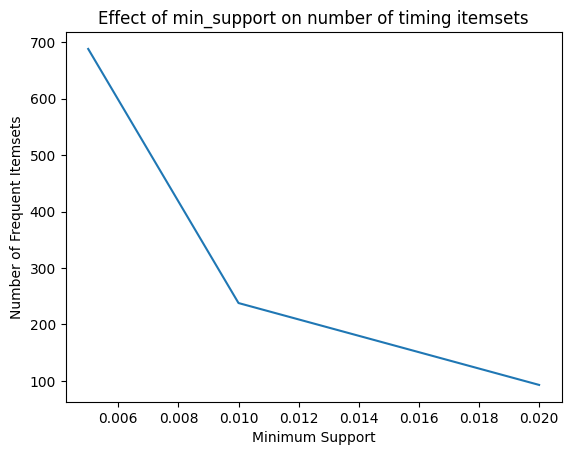

In [42]:
# Plot how min_support affects the number of frequent itemsets
supports_plot = [r[0] for r in timing_itemset_counts]
counts_plot = [r[1] for r in timing_itemset_counts]

plt.figure()
plt.plot(supports_plot, counts_plot)
plt.xlabel("Minimum Support")
plt.ylabel("Number of Frequent Itemsets")
plt.title("Effect of min_support on number of timing itemsets")
plt.show()

In [43]:
# Frequent itemset table to generate rules with different confidence thresholds
timing_frequent_base = apriori(timing_encoded_df, min_support=0.005, use_colnames=True)

timing_conf_levels = [0.1, 0.2, 0.3, 0.4]
timing_rule_counts = []

for c in timing_conf_levels:
    timing_rules = association_rules(timing_frequent_base, metric="confidence", min_threshold=c)
    timing_rule_counts.append(len(timing_rules))

list(zip(timing_conf_levels, timing_rule_counts))

[(0.1, 584), (0.2, 304), (0.3, 227), (0.4, 135)]

In [44]:
# Store rules for each confidence level so we can inspect and sort them
timing_rules_by_conf = {}

for c in timing_conf_levels:
    timing_rules_by_conf[c] = association_rules(
        timing_frequent_base,
        metric="confidence",
        min_threshold=c
    )

In [45]:
for c in timing_conf_levels:
    print(f"\n confidence >= {c}")
    display(
        timing_rules_by_conf[c]
        .sort_values("confidence", ascending=False)
        .head(10)
    )


 confidence >= 0.1


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
522,"(Banana, sunday)",(afternoon),0.030426,0.471608,0.015847,0.520833,1.104377,1.0,0.001498,1.102731,0.097478,0.032595,0.093160,0.277218
575,"(Organic Hass Avocado, sunday)",(afternoon),0.012269,0.471608,0.006339,0.516667,1.095542,1.0,0.000553,1.093224,0.088293,0.013274,0.085275,0.265054
113,(Clementines),(morning),0.009917,0.331152,0.005010,0.505155,1.525445,1.0,0.001726,1.351630,0.347904,0.014907,0.260152,0.260141
397,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
172,(Michigan Organic Kale),(afternoon),0.020427,0.471608,0.010306,0.504505,1.069753,1.0,0.000672,1.066391,0.066565,0.021393,0.062257,0.263178
556,"(Organic Avocado, sunday)",(afternoon),0.012391,0.471608,0.006196,0.500000,1.060202,1.0,0.000352,1.056784,0.057496,0.012967,0.053732,0.256569
134,(Large Alfresco Eggs),(afternoon),0.012637,0.471608,0.006318,0.500000,1.060202,1.0,0.000359,1.056784,0.057510,0.013220,0.053732,0.256699
463,"(Bag of Organic Bananas, sunday)",(afternoon),0.022349,0.471608,0.011103,0.496798,1.053412,1.0,0.000563,1.050059,0.051863,0.022995,0.047672,0.260170
363,(Roma Tomato),(afternoon),0.013168,0.471608,0.006523,0.495342,1.050324,1.0,0.000313,1.047029,0.048553,0.013639,0.044916,0.254586
371,(Sparkling Water Grapefruit),(afternoon),0.023883,0.471608,0.011819,0.494863,1.049310,1.0,0.000555,1.046037,0.048142,0.024436,0.044011,0.259962



 confidence >= 0.2


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
275,"(Banana, sunday)",(afternoon),0.030426,0.471608,0.015847,0.520833,1.104377,1.0,0.001498,1.102731,0.097478,0.032595,0.093160,0.277218
298,"(Organic Hass Avocado, sunday)",(afternoon),0.012269,0.471608,0.006339,0.516667,1.095542,1.0,0.000553,1.093224,0.088293,0.013274,0.085275,0.265054
57,(Clementines),(morning),0.009917,0.331152,0.005010,0.505155,1.525445,1.0,0.001726,1.351630,0.347904,0.014907,0.260152,0.260141
220,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
87,(Michigan Organic Kale),(afternoon),0.020427,0.471608,0.010306,0.504505,1.069753,1.0,0.000672,1.066391,0.066565,0.021393,0.062257,0.263178
77,(Large Alfresco Eggs),(afternoon),0.012637,0.471608,0.006318,0.500000,1.060202,1.0,0.000359,1.056784,0.057510,0.013220,0.053732,0.256699
288,"(Organic Avocado, sunday)",(afternoon),0.012391,0.471608,0.006196,0.500000,1.060202,1.0,0.000352,1.056784,0.057496,0.012967,0.053732,0.256569
246,"(Bag of Organic Bananas, sunday)",(afternoon),0.022349,0.471608,0.011103,0.496798,1.053412,1.0,0.000563,1.050059,0.051863,0.022995,0.047672,0.260170
196,(Roma Tomato),(afternoon),0.013168,0.471608,0.006523,0.495342,1.050324,1.0,0.000313,1.047029,0.048553,0.013639,0.044916,0.254586
204,(Sparkling Water Grapefruit),(afternoon),0.023883,0.471608,0.011819,0.494863,1.049310,1.0,0.000555,1.046037,0.048142,0.024436,0.044011,0.259962



 confidence >= 0.3


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
205,"(Banana, sunday)",(afternoon),0.030426,0.471608,0.015847,0.520833,1.104377,1.0,0.001498,1.102731,0.097478,0.032595,0.093160,0.277218
222,"(Organic Hass Avocado, sunday)",(afternoon),0.012269,0.471608,0.006339,0.516667,1.095542,1.0,0.000553,1.093224,0.088293,0.013274,0.085275,0.265054
26,(Clementines),(morning),0.009917,0.331152,0.005010,0.505155,1.525445,1.0,0.001726,1.351630,0.347904,0.014907,0.260152,0.260141
163,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
51,(Michigan Organic Kale),(afternoon),0.020427,0.471608,0.010306,0.504505,1.069753,1.0,0.000672,1.066391,0.066565,0.021393,0.062257,0.263178
215,"(Organic Avocado, sunday)",(afternoon),0.012391,0.471608,0.006196,0.500000,1.060202,1.0,0.000352,1.056784,0.057496,0.012967,0.053732,0.256569
44,(Large Alfresco Eggs),(afternoon),0.012637,0.471608,0.006318,0.500000,1.060202,1.0,0.000359,1.056784,0.057510,0.013220,0.053732,0.256699
184,"(Bag of Organic Bananas, sunday)",(afternoon),0.022349,0.471608,0.011103,0.496798,1.053412,1.0,0.000563,1.050059,0.051863,0.022995,0.047672,0.260170
140,(Roma Tomato),(afternoon),0.013168,0.471608,0.006523,0.495342,1.050324,1.0,0.000313,1.047029,0.048553,0.013639,0.044916,0.254586
148,(Sparkling Water Grapefruit),(afternoon),0.023883,0.471608,0.011819,0.494863,1.049310,1.0,0.000555,1.046037,0.048142,0.024436,0.044011,0.259962



 confidence >= 0.4


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
120,"(Banana, sunday)",(afternoon),0.030426,0.471608,0.015847,0.520833,1.104377,1.0,0.001498,1.102731,0.097478,0.032595,0.093160,0.277218
131,"(Organic Hass Avocado, sunday)",(afternoon),0.012269,0.471608,0.006339,0.516667,1.095542,1.0,0.000553,1.093224,0.088293,0.013274,0.085275,0.265054
12,(Clementines),(morning),0.009917,0.331152,0.005010,0.505155,1.525445,1.0,0.001726,1.351630,0.347904,0.014907,0.260152,0.260141
96,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
28,(Michigan Organic Kale),(afternoon),0.020427,0.471608,0.010306,0.504505,1.069753,1.0,0.000672,1.066391,0.066565,0.021393,0.062257,0.263178
24,(Large Alfresco Eggs),(afternoon),0.012637,0.471608,0.006318,0.500000,1.060202,1.0,0.000359,1.056784,0.057510,0.013220,0.053732,0.256699
125,"(Organic Avocado, sunday)",(afternoon),0.012391,0.471608,0.006196,0.500000,1.060202,1.0,0.000352,1.056784,0.057496,0.012967,0.053732,0.256569
107,"(Bag of Organic Bananas, sunday)",(afternoon),0.022349,0.471608,0.011103,0.496798,1.053412,1.0,0.000563,1.050059,0.051863,0.022995,0.047672,0.260170
80,(Roma Tomato),(afternoon),0.013168,0.471608,0.006523,0.495342,1.050324,1.0,0.000313,1.047029,0.048553,0.013639,0.044916,0.254586
86,(Sparkling Water Grapefruit),(afternoon),0.023883,0.471608,0.011819,0.494863,1.049310,1.0,0.000555,1.046037,0.048142,0.024436,0.044011,0.259962


In [46]:
# Sort rules by support
for c in timing_conf_levels:
    print(f"\nconfidence >= {c}")
    display(
        timing_rules_by_conf[c]
        .assign(support=pd.to_numeric(timing_rules_by_conf[c]["support"], errors="coerce"))
        .sort_values("support", ascending=False)
        .head(10)
    )


confidence >= 0.1


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
396,(afternoon),(sunday),0.471608,0.173684,0.087680,0.185917,1.070437,1.0,0.005770,1.015028,0.124533,0.157242,0.014805,0.345372
397,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
392,(monday),(afternoon),0.170841,0.471608,0.077824,0.455536,0.965920,1.0,-0.002746,0.970480,-0.040816,0.137834,-0.030418,0.310277
393,(afternoon),(monday),0.471608,0.170841,0.077824,0.165019,0.965920,1.0,-0.002746,0.993027,-0.062594,0.137834,-0.007022,0.310277
85,(afternoon),(Banana),0.471608,0.146795,0.066926,0.141909,0.966720,1.0,-0.002304,0.994307,-0.061167,0.121357,-0.005726,0.298911
84,(Banana),(afternoon),0.146795,0.471608,0.066926,0.455913,0.966720,1.0,-0.002304,0.971153,-0.038784,0.121357,-0.029704,0.298911
400,(tuesday),(afternoon),0.138329,0.471608,0.063940,0.462232,0.980119,1.0,-0.001297,0.982565,-0.022999,0.117107,-0.017745,0.298906
401,(afternoon),(tuesday),0.471608,0.138329,0.063940,0.135579,0.980119,1.0,-0.001297,0.996818,-0.036970,0.117107,-0.003192,0.298906
420,(monday),(morning),0.170841,0.331152,0.063490,0.371634,1.122244,1.0,0.006916,1.064423,0.131372,0.144789,0.060524,0.281680
421,(morning),(monday),0.331152,0.170841,0.063490,0.191726,1.122244,1.0,0.006916,1.025838,0.162860,0.144789,0.025187,0.281680



confidence >= 0.2


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
220,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
218,(monday),(afternoon),0.170841,0.471608,0.077824,0.455536,0.965920,1.0,-0.002746,0.970480,-0.040816,0.137834,-0.030418,0.310277
45,(Banana),(afternoon),0.146795,0.471608,0.066926,0.455913,0.966720,1.0,-0.002304,0.971153,-0.038784,0.121357,-0.029704,0.298911
222,(tuesday),(afternoon),0.138329,0.471608,0.063940,0.462232,0.980119,1.0,-0.001297,0.982565,-0.022999,0.117107,-0.017745,0.298906
225,(monday),(morning),0.170841,0.331152,0.063490,0.371634,1.122244,1.0,0.006916,1.064423,0.131372,0.144789,0.060524,0.281680
219,(saturday),(afternoon),0.131827,0.471608,0.062979,0.477742,1.013005,1.0,0.000809,1.011744,0.014788,0.116530,0.011608,0.305642
217,(friday),(afternoon),0.132911,0.471608,0.061384,0.461846,0.979300,1.0,-0.001297,0.981860,-0.023797,0.113019,-0.018475,0.296003
223,(wednesday),(afternoon),0.127533,0.471608,0.060382,0.473465,1.003937,1.0,0.000237,1.003526,0.004494,0.112077,0.003514,0.300750
221,(thursday),(afternoon),0.124875,0.471608,0.057417,0.459800,0.974962,1.0,-0.001475,0.978141,-0.028509,0.106513,-0.022347,0.290774
23,(Bag of Organic Bananas),(afternoon),0.117411,0.471608,0.053532,0.455939,0.966774,1.0,-0.001840,0.971199,-0.037480,0.099969,-0.029655,0.284724



confidence >= 0.3


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
163,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
161,(monday),(afternoon),0.170841,0.471608,0.077824,0.455536,0.965920,1.0,-0.002746,0.970480,-0.040816,0.137834,-0.030418,0.310277
15,(Banana),(afternoon),0.146795,0.471608,0.066926,0.455913,0.966720,1.0,-0.002304,0.971153,-0.038784,0.121357,-0.029704,0.298911
165,(tuesday),(afternoon),0.138329,0.471608,0.063940,0.462232,0.980119,1.0,-0.001297,0.982565,-0.022999,0.117107,-0.017745,0.298906
168,(monday),(morning),0.170841,0.331152,0.063490,0.371634,1.122244,1.0,0.006916,1.064423,0.131372,0.144789,0.060524,0.281680
162,(saturday),(afternoon),0.131827,0.471608,0.062979,0.477742,1.013005,1.0,0.000809,1.011744,0.014788,0.116530,0.011608,0.305642
160,(friday),(afternoon),0.132911,0.471608,0.061384,0.461846,0.979300,1.0,-0.001297,0.981860,-0.023797,0.113019,-0.018475,0.296003
166,(wednesday),(afternoon),0.127533,0.471608,0.060382,0.473465,1.003937,1.0,0.000237,1.003526,0.004494,0.112077,0.003514,0.300750
164,(thursday),(afternoon),0.124875,0.471608,0.057417,0.459800,0.974962,1.0,-0.001475,0.978141,-0.028509,0.106513,-0.022347,0.290774
9,(Bag of Organic Bananas),(afternoon),0.117411,0.471608,0.053532,0.455939,0.966774,1.0,-0.001840,0.971199,-0.037480,0.099969,-0.029655,0.284724



confidence >= 0.4


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
96,(sunday),(afternoon),0.173684,0.471608,0.087680,0.504827,1.070437,1.0,0.005770,1.067085,0.079633,0.157242,0.062868,0.345372
94,(monday),(afternoon),0.170841,0.471608,0.077824,0.455536,0.965920,1.0,-0.002746,0.970480,-0.040816,0.137834,-0.030418,0.310277
5,(Banana),(afternoon),0.146795,0.471608,0.066926,0.455913,0.966720,1.0,-0.002304,0.971153,-0.038784,0.121357,-0.029704,0.298911
98,(tuesday),(afternoon),0.138329,0.471608,0.063940,0.462232,0.980119,1.0,-0.001297,0.982565,-0.022999,0.117107,-0.017745,0.298906
95,(saturday),(afternoon),0.131827,0.471608,0.062979,0.477742,1.013005,1.0,0.000809,1.011744,0.014788,0.116530,0.011608,0.305642
93,(friday),(afternoon),0.132911,0.471608,0.061384,0.461846,0.979300,1.0,-0.001297,0.981860,-0.023797,0.113019,-0.018475,0.296003
99,(wednesday),(afternoon),0.127533,0.471608,0.060382,0.473465,1.003937,1.0,0.000237,1.003526,0.004494,0.112077,0.003514,0.300750
97,(thursday),(afternoon),0.124875,0.471608,0.057417,0.459800,0.974962,1.0,-0.001475,0.978141,-0.028509,0.106513,-0.022347,0.290774
4,(Bag of Organic Bananas),(afternoon),0.117411,0.471608,0.053532,0.455939,0.966774,1.0,-0.001840,0.971199,-0.037480,0.099969,-0.029655,0.284724
67,(Organic Strawberries),(afternoon),0.083448,0.471608,0.037849,0.453565,0.961742,1.0,-0.001506,0.966981,-0.041597,0.073179,-0.034147,0.266910
